In [25]:
import re
import glob
import pickle
import pandas as pd
import numpy as np


In [26]:
DATA_DIR = "outputs"
FILENAME_PATTERN = re.compile(r"sample_x(\d+)_(.+)-mas\.dat")

CACHE_TIMESERIES = "mas_data_all.pkl"
CACHE_SUMMARY = "mas_summary.csv"

In [27]:


def read_mas(filename):
    """Read a PFLOTRAN -mas.dat file into a DataFrame (handles the
    comma-separated quoted header + whitespace-separated data rows)."""
    with open(filename) as f:
        header_line = f.readline()
    columns = [c.strip().strip('"') for c in header_line.strip().split(",")]
    df = pd.read_csv(filename, skiprows=1, sep=r"\s+", names=columns)
    return df


def discover_files(data_dir=DATA_DIR):
    """Find every sample/case .dat file and parse out (sample, case)."""
    files = []
    for path in sorted(glob.glob(f"{data_dir}/sample_x*-mas.dat")):
        m = FILENAME_PATTERN.search(path)
        if not m:
            continue
        sample = int(m.group(1))
        case = m.group(2)
        files.append((sample, case, path))
    return files


def load_all_data(data_dir=DATA_DIR, use_cache=False):
    """Load every sample/case time series into a nested dict:
        data[case][sample] -> DataFrame
    Cached to disk (pickle) since re-parsing hundreds of .dat files
    is slow and the raw data doesn't change once a run is done.
    """
    if use_cache:
        try:
            with open(CACHE_TIMESERIES, "rb") as f:
                return pickle.load(f)
        except FileNotFoundError:
            pass

    data = {}
    for sample, case, path in discover_files(data_dir):
        df = read_mas(path)
        data.setdefault(case, {})[sample] = df

    with open(CACHE_TIMESERIES, "wb") as f:
        pickle.dump(data, f)

    return data


def summarize_run(df):
    """Collapse one sample/case time series to scalar metrics useful
    for cross-case, cross-sample comparison."""
    time = df["Time [y]"]
    rate = -1 * df["OUTFLOW Tracer1 [mol/y]"]
    cumulative = -1 * df["OUTFLOW Tracer1 [mol]"]

    total = cumulative.max()
    cdf = cumulative / total if total != 0 else cumulative * 0

    peak_idx = rate.idxmax()

    # first time the CDF crosses 0.5 (median breakthrough time)
    above_half = cdf >= 0.5
    t50 = time[above_half].iloc[0] if above_half.any() else np.nan

    return {
        "peak_rate": rate.loc[peak_idx],
        "peak_time": time.loc[peak_idx],
        "t50_breakthrough": t50,
        "final_cumulative_mol": total,
        "n_timesteps": len(df),
    }


def build_summary(data, use_cache=True):
    """Tidy one-row-per-(case, sample) summary table, e.g. for
    groupby(case).describe() or boxplots across samples."""
    if use_cache:
        try:
            return pd.read_csv(CACHE_SUMMARY)
        except FileNotFoundError:
            pass

    rows = []
    for case, samples in data.items():
        for sample, df in samples.items():
            row = {"case": case, "sample": sample}
            row.update(summarize_run(df))
            rows.append(row)

    summary = pd.DataFrame(rows).sort_values(["case", "sample"]).reset_index(drop=True)
    summary.to_csv(CACHE_SUMMARY, index=False)
    return summary



In [28]:


data = load_all_data()
summary = build_summary(data)

print(f"Loaded {sum(len(s) for s in data.values())} runs "
      f"across {len(data)} cases")




# stack every case, every sample into one long-format DataFrame
combined = pd.concat(
    [
        df.assign(case=case, sample=sample)
        for case, samples in data.items()
        for sample, df in samples.items()
    ],
    ignore_index=True,
)

combined.to_csv("all_cases_all_samples.csv", index=False)
# or, more compact / faster to reload:
# combined.to_parquet("all_cases_all_samples.parquet", index=False)

print(combined.shape)
print(combined[["case", "sample"]].drop_duplicates().reset_index(drop=True))




Loaded 70 runs across 9 cases
(18970, 15)
       case  sample
0    Case_0       1
1    Case_0       2
2    Case_0       3
3    Case_0       4
4    Case_0       5
..      ...     ...
65  Case_3b       3
66  Case_3b       4
67  Case_3b       5
68  Case_3b       6
69  Case_3b       7

[70 rows x 2 columns]


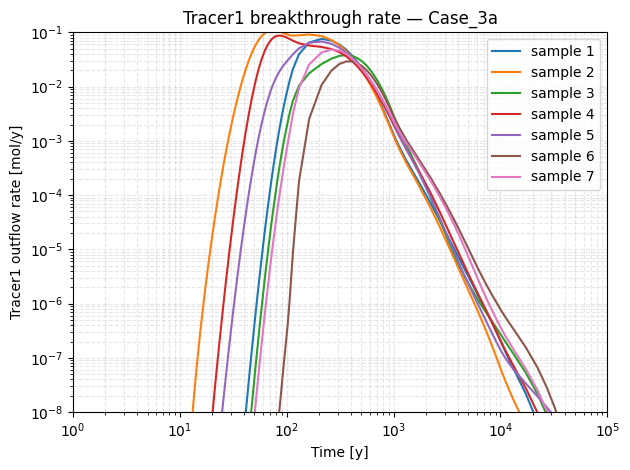

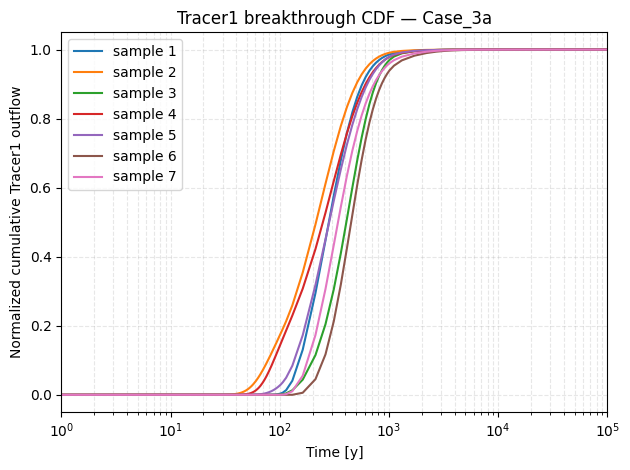

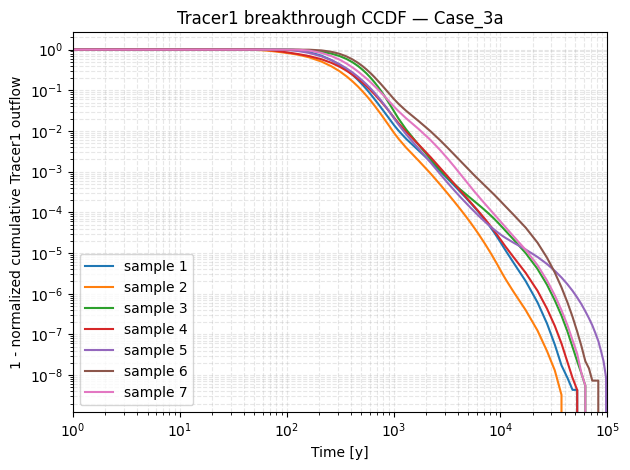

In [29]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- pick a case here ---
case = "Case_3a"

samples = sorted(data[case].keys())

colors = cm.tab10.colors
sample_colors = {sample: colors[i % len(colors)] for i, sample in enumerate(samples)}

fig, ax = plt.subplots()
fig_cdf, ax_cdf = plt.subplots()
fig_ccdf, ax_ccdf = plt.subplots()

for sample in samples:
    df = data[case][sample]

    outflow_rate = -1 * df["OUTFLOW Tracer1 [mol/y]"]
    outflow_cumulative = -1 * df["OUTFLOW Tracer1 [mol]"]
    cdf = outflow_cumulative / outflow_cumulative.max()
    ccdf = 1 - cdf

    color = sample_colors[sample]
    label = f"sample {sample}"

    ax.loglog(df["Time [y]"], outflow_rate, label=label, color=color)
    ax_cdf.semilogx(df["Time [y]"], cdf, label=label, color=color)
    ax_ccdf.loglog(df["Time [y]"], ccdf, label=label, color=color)

ax.set_xlabel("Time [y]")
ax.set_ylabel("Tracer1 outflow rate [mol/y]")
ax.set_title(f"Tracer1 breakthrough rate — {case}")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.3)
ax.set_xlim(1, 10**5)
ax.set_ylim(10**-8, 10**-1)

ax_cdf.set_xlabel("Time [y]")
ax_cdf.set_ylabel("Normalized cumulative Tracer1 outflow")
ax_cdf.set_title(f"Tracer1 breakthrough CDF — {case}")
ax_cdf.legend()
ax_cdf.grid(True, which="both", ls="--", alpha=0.3)
ax_cdf.set_xlim(1, 10**5)
ax_cdf.set_ylim(-0.05, 1.05)

ax_ccdf.set_xlabel("Time [y]")
ax_ccdf.set_ylabel("1 - normalized cumulative Tracer1 outflow")
ax_ccdf.set_title(f"Tracer1 breakthrough CCDF — {case}")
ax_ccdf.legend()
ax_ccdf.grid(True, which="both", ls="--", alpha=0.3)
ax_ccdf.set_xlim(1, 10**5)

fig.tight_layout()
fig_cdf.tight_layout()
fig_ccdf.tight_layout()

plt.show()